# Strategy Sensitivity — toxicity weighting γ · sentiment moving-average window

Re-deriving **K-FGI → position → strategy return** over the full 10 years for varying parameters, comparing Sharpe · MDD · CVaR(5%) · downside vol · down-day defense · Calmar.

- Experiment 1: γ ∈ {1, 2, 3} — recompute the 6 daily sentiment features → swap into `KFG_final` → re-run the whole pipeline
- Experiment 2: sentiment-composite moving-average window ∈ {5, 10, 20} trading days (γ = 2 fixed)

**Note** — EGARCH conditional volatility depends only on returns, so its cache (`08_Modeling/experiment_outputs/cache/egarch_vol_10y.csv`) is reused. The walk-forward K-FGI re-estimation makes 6 runs take ~8–12 min. Results are saved to `downstream_sensitivity.csv`.

In [1]:
import pandas as pd, numpy as np
import downstream_strategy_sensitivity as D
import filter_param_lib as L
%matplotlib inline
import matplotlib.pyplot as plt
LANG = "en"
L.use_style(LANG)

## Run
First run takes 8–12 min. If `downstream_sensitivity.csv` already exists, you can run only the table/figure cells below.

In [2]:
kfg = pd.read_csv(D.KFG_FINAL, parse_dates=['date']).sort_values('date').reset_index(drop=True)
mkt = kfg[['date','log_return_t+1']].rename(columns={'log_return_t+1':'mkt'}).set_index('date')['mkt']
comments = D.load_comments()
SENT = ['sent_norm_w','sent_strength_w','sent_std','neg_z','effective_n','heat']
def swap_sent(gamma):
    ds = D.daily_sentiment(comments, gamma)
    m = kfg.drop(columns=SENT).merge(ds, on='date', how='left')
    m[SENT] = m[SENT].ffill()
    return m

In [3]:
# downstream_sensitivity.csv 가 이미 있으면 재사용한다. 다시 계산하려면 그 파일을 삭제하고 실행.
CSV = D.BASE / 'downstream_sensitivity.csv'
if CSV.exists():
    out = pd.read_csv(CSV)
    print('loaded cached', CSV.name)
else:
    rows = []
    for g in [1.0, 2.0, 3.0]:
        res = D.run_pipeline(swap_sent(g), sent_ma_window=10)
        mm = D.metrics(res['strat_ret'].reset_index(drop=True), mkt.reindex(res['date']).reset_index(drop=True), f'gamma={g:g}')
        mm['experiment'], mm['param'] = 'gamma', g; rows.append(mm); print('gamma', g, 'done')
    base2 = swap_sent(2.0)
    for w in [5, 10, 20]:
        res = D.run_pipeline(base2, sent_ma_window=w)
        mm = D.metrics(res['strat_ret'].reset_index(drop=True), mkt.reindex(res['date']).reset_index(drop=True), f'sent_MA={w}')
        mm['experiment'], mm['param'] = 'sent_ma', w; rows.append(mm); print('sent_MA', w, 'done')
    out = pd.DataFrame(rows); out.to_csv(CSV, index=False)
out[['experiment','param','sharpe','mdd','cvar5','downside_vol','downday_defense','calmar','total_return']].round(4)

loaded cached downstream_sensitivity.csv


,experiment,param,sharpe,mdd,cvar5,downside_vol,downday_defense,calmar,total_return
0,gamma,1.0,0.6096,-0.2291,-0.0213,0.1144,0.5872,0.3619,1.2804
1,gamma,2.0,0.6127,-0.2293,-0.0213,0.1143,0.5863,0.3633,1.2892
2,gamma,3.0,0.6222,-0.2291,-0.0213,0.1145,0.5867,0.3703,1.3237
3,sent_ma,5.0,0.5459,-0.2535,-0.0217,0.1171,0.6031,0.2972,1.1148
4,sent_ma,10.0,0.6127,-0.2293,-0.0213,0.1143,0.5863,0.3633,1.2892
5,sent_ma,20.0,0.5391,-0.2732,-0.0234,0.1258,0.6404,0.2906,1.2017


## Results

### H1

Result of re-deriving comment → daily sentiment features → K-FGI → position → strategy return over the full 10 years for γ = 1, 2, 3. Sharpe 0.610 / 0.613 / 0.622 and Calmar near 0.36 — essentially flat. γ=2 is not a performance optimum.

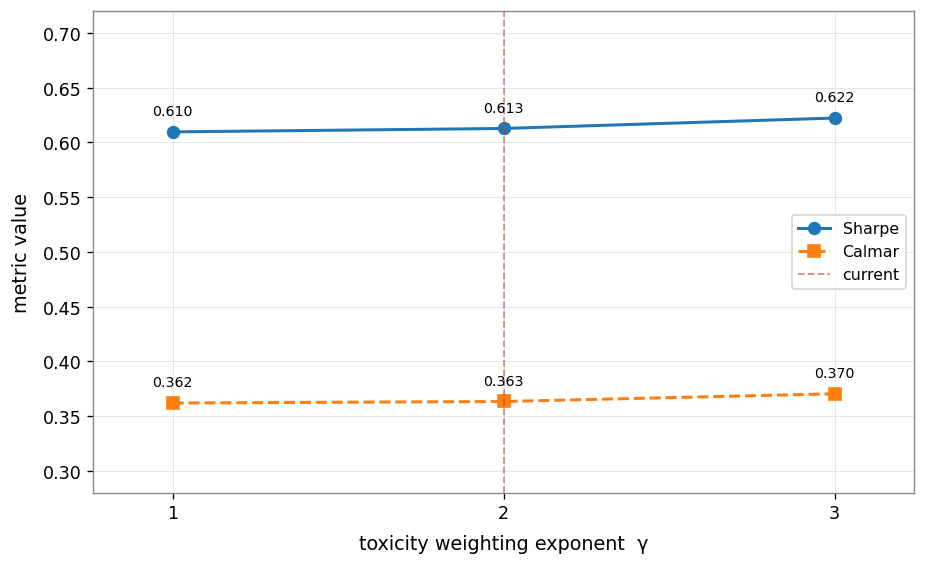

In [4]:
L.make_fig("H1", None, LANG)

### H2

MDD −22.9%, CVaR (5%) −2.13%, downside volatility 0.114 — unchanged to three decimals from γ 1 to 3. The toxicity weighting exponent does not affect the strategy's downside risk.

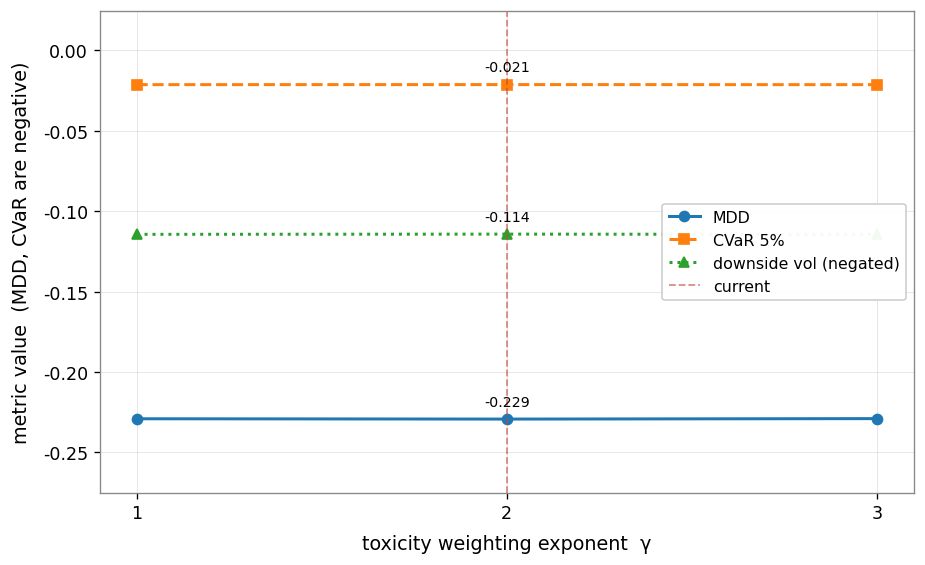

In [5]:
L.make_fig("H2", None, LANG)

### I1

Strategy performance when sent_composite is smoothed over 5, 10 or 20 trading days. 10 days is a clear local optimum on Sharpe (0.61), Calmar (0.36) and MDD (−22.9%). 5 days is noisy, 20 days lags. (Unlike τ and γ, this value does move the result, so it needs an explicit rationale.)

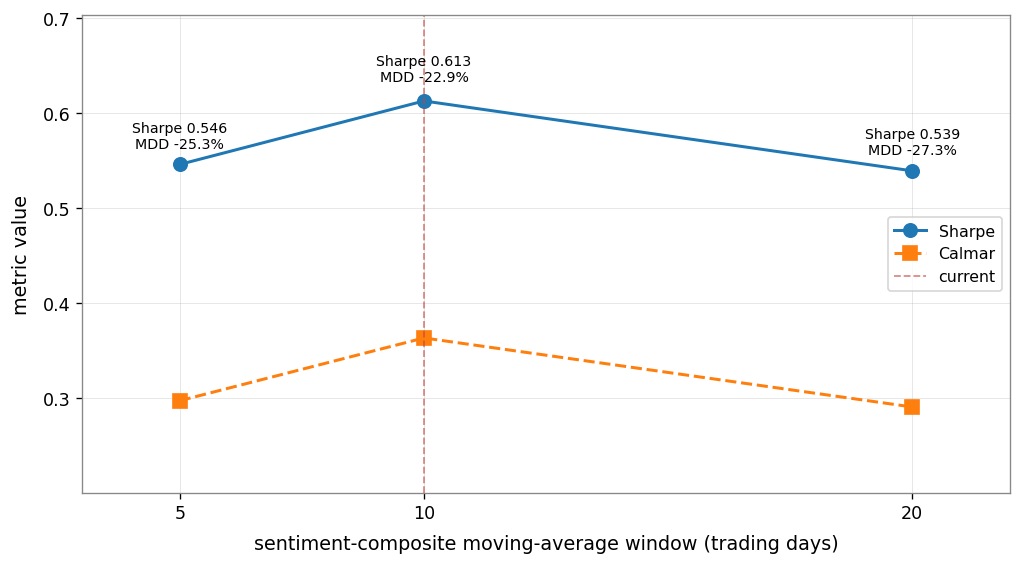

In [6]:
L.make_fig("I1", None, LANG)

## Reading

- **γ has no effect on strategy performance.** Sharpe 0.610 / 0.613 / 0.622 for γ 1/2/3, MDD fixed at −22.9%. So γ = 2 was chosen on the comment-weighting principle (halve a borderline-toxic comment), not for performance.
- **The 10-day sentiment MA is a clear local optimum.** 5 days (Sharpe 0.55) is noisy, 20 days (Sharpe 0.54, MDD −27.3%) lags. Unlike τ and γ, this value does move the result and therefore needs an explicit rationale — this table is that rationale.